In [1]:
using JuMP, Gurobi, CSV, DataFrames, Statistics, LinearAlgebra

In [2]:
model = Model(optimizer_with_attributes(Gurobi.Optimizer,
    "TimeLimit" => 3600,
    "MIPGap" => 0.01 # 1% optimality gap
))

Set parameter Username
Set parameter LicenseID to value 2725701
Academic license - for non-commercial use only - expires 2026-10-21
Set parameter TimeLimit to value 3600
Set parameter MIPGap to value 0.01


A JuMP Model
├ solver: Gurobi
├ objective_sense: FEASIBILITY_SENSE
├ num_variables: 0
├ num_constraints: 0
└ Names registered in the model: none

In [ ]:
plant_details_df = CSV.read("cleaned_plant_locations.csv", DataFrame; header=false)
distance_df = CSV.read("distance_mtx.csv", DataFrame; header=false)

# making statistics to replace broken data (NaN values, etc)
valid_values = Float64[]
for i in 1:size(distance_df, 1)
    for j in 1:size(distance_df, 2)
        val = distance_df[i, j]
        if val isa AbstractString
            parsed = tryparse(Float64, string(val))
            if !isnothing(parsed)
                push!(valid_values, parsed)
            end
        else
            push!(valid_values, Float64(val))
        end
    end
end

# Compute statistics on valid values
max_valid = isempty(valid_values) ? 1_000_000.0 : maximum(valid_values)
mean_valid = isempty(valid_values) ? 1_000.0 : mean(valid_values)

# Initialize distance_mtx_raw
distance_mtx_raw = Matrix{Float64}(undef, size(distance_df, 1), size(distance_df, 2))

# Convert to numeric matrix with error handling
for i in 1:size(distance_df, 1)
    for j in 1:size(distance_df, 2)
        val = distance_df[i, j]
        if val isa AbstractString
            str_val = string(val)
            if str_val == "NET_ERR"
                distance_mtx_raw[i, j] = max_valid * 100.0
            else
                # Try to parse other strings
                parsed = tryparse(Float64, str_val)
                if isnothing(parsed)
                    # If still can't parse, use mean of valid values
                    distance_mtx_raw[i, j] = mean_valid
                else
                    distance_mtx_raw[i, j] = parsed
                end
            end
        else
            distance_mtx_raw[i, j] = Float64(val)
        end
    end
end

# meters to miles
distance_mtx_raw .*= 0.000621371

fixed_cost = 200000.0
variable_cost = 125.0
transportation_cost = 3.14
delta = 0.95

plant_details = Matrix(plant_details_df)

year_exps_raw = plant_details[:, 4]
tons_waste = plant_details[:, 5] .* 200.0

year_exps = Int[]
for i in 1:338
    push!(year_exps, year_exps_raw[i] - 2009) # first expires in 2010
end

# Compute tight big-M based on total waste
M = sum(tons_waste) + 1.0

# Group plants by expiration year for efficiency
plants_per_year = [[s for s in 1:338 if year_exps[s] == t] for t in 1:10]

@variable(model, x[1:95, 1:10], Bin)           # whether or not location i is active in year t
@variable(model, y[1:95] >= 0)                 # size in tons of location i
@variable(model, z[1:338, 1:95] >= 0)          # how many tons waste from plant s to facility i when it expires
@variable(model, e[1:95], Bin)                 # whether or not facility exists at all
@variable(model, b[1:95, 1:10], Bin)           # year location first opens (only 1 for one year if open)
@variable(model, a[1:95, 1:10], Bin)           # years after location first open (becomes 1 and fixes as 1 after opening)
@variable(model, w[1:95, 1:10] >= 0)           # bilinear term x[i,t]*y[i]

# Facility existence constraints
@constraint(model, [i=1:95, t=1:10], e[i] >= x[i,t])
@constraint(model, [i=1:95], e[i] <= sum(x[i,t] for t in 1:10))

# Capacity constraints
@constraint(model, [i=1:95], y[i] <= M * e[i])
@constraint(model, [i=1:95], y[i] >= e[i])

# First time location opens
@constraint(model, [i=1:95], b[i,1] == x[i,1])
@constraint(model, [i=1:95, t=2:10], b[i,t] >= b[i,t-1])
@constraint(model, [i=1:95, t=2:10], b[i,t] >= x[i,t])
@constraint(model, [i=1:95, t=2:10], b[i,t] <= b[i,t-1] + x[i,t])

# Enforcing discount Factor
@constraint(model, [i=1:95], sum(a[i,t] for t in 1:10) == e[i])
@constraint(model, [i=1:95, t=1:10], a[i,t] <= b[i,t])
@constraint(model, [i=1:95], a[i,1] >= b[i,1])
@constraint(model, [i=1:95], a[i,1] <= b[i,1])
@constraint(model, [i=1:95, t=2:10], a[i,t] >= b[i,t] - b[i,t-1])
@constraint(model, [i=1:95, t=2:10], a[i,t] <= b[i,t] - b[i,t-1])

# Linearized x[i,t] * y[i]
@constraint(model, [i=1:95, t=1:10], w[i,t] <= M * x[i,t])
@constraint(model, [i=1:95, t=1:10], w[i,t] <= y[i])
@constraint(model, [i=1:95, t=1:10], w[i,t] >= y[i] - M * (1 - x[i,t]))

# Waste allocation constraints
for s in 1:338
    @constraint(model, sum(z[s,j] for j in 1:95) == tons_waste[s])
    @constraint(model, [j=1:95], z[s,j] <= y[j])
end

# Add constraint to tie processing to operating capacity (in the expiration year)
for t in 1:10
    for i in 1:95
        @constraint(model, sum(z[s,i] for s in plants_per_year[t]) <= w[i,t])
    end
end

discount_factors = [delta^t for t in 1:10]

@objective(model, Min,
    sum(
        # Fixed cost with discount
        sum(a[i,t] * discount_factors[t] * fixed_cost for t in 1:10) +
        
        # Variable cost with annual discounting
        sum(
            w[i,t] * discount_factors[t] * variable_cost 
            for t in 1:10
        )
        for i in 1:95
    ) +
    # Transportation cost without discount
    sum(
        sum(z[s,i] * distance_mtx_raw[i,s] * transportation_cost 
            for s in 1:338)
        for i in 1:95
    )
)

optimize!(model)
println(termination_status(model))

Set parameter MIPGap to value 0.01
Set parameter TimeLimit to value 3600
Gurobi Optimizer version 12.0.3 build v12.0.3rc0 (win64 - Windows 11.0 (22631.2))

CPU model: Intel(R) Core(TM) Ultra 7 165H, instruction set [SSE2|AVX|AVX2]
Thread count: 16 physical cores, 22 logical processors, using up to 22 threads

Non-default parameters:
TimeLimit  3600
MIPGap  0.01

Optimize a model with 43088 rows, 36100 columns and 153995 nonzeros
Model fingerprint: 0x555b5689
Variable types: 33155 continuous, 2945 integer (2945 binary)
Coefficient statistics:
  Matrix range     [1e+00, 2e+05]
  Objective range  [2e+00, 2e+05]
  Bounds range     [0e+00, 0e+00]
  RHS range        [6e+01, 2e+05]
Presolve removed 5142 rows and 2280 columns
Presolve time: 0.30s
Presolved: 37946 rows, 33820 columns, 139840 nonzeros
Variable types: 32015 continuous, 1805 integer (1805 binary)
Found heuristic solution: objective 1.176530e+08
Found heuristic solution: objective 1.145785e+08
Deterministic concurrent LP optimizer:

In [4]:
# Get solution values
y_val = value.(y)
x_val = value.(x)
z_val = value.(z)
e_val = value.(e)
open_facilities = findall(e_val .> 0.5)
println(open_facilities)
for year in 1:10
    operating_in_year = x_val[:, year]
    operating_active = findall(operating_in_year .> 0.5)
    println(operating_active)
end

println(y_val)

println(x_val)

[2, 4, 9, 11, 14, 19, 25, 26, 29, 31, 33, 34, 39, 43, 45, 46, 52, 63, 67, 71, 74, 76, 91, 92, 95]
[31, 67]
[25, 31]
[2, 14, 25, 31, 33, 67, 91, 95]
[2, 14, 19, 25, 31, 33, 43, 46, 63, 74, 76, 91, 95]
[2, 4, 9, 11, 14, 25, 29, 31, 33, 39, 43, 45, 74, 76, 91, 95]
[2, 9, 14, 25, 43, 46, 52, 63]
[9, 14, 25, 29, 31, 33, 43, 45, 46, 52, 63, 76, 91, 95]
[4, 9, 14, 19, 25, 26, 29, 31, 33, 34, 39, 45, 46, 52, 63, 67, 71, 76, 91, 92, 95]
[2, 9, 14, 31, 39, 43, 46, 52, 63, 71, 74, 92]
[14, 25, 26, 31, 39, 43, 52, 67, 71, 74, 76, 95]
[0.0, 1530.0, 0.0, 1830.0, 0.0, 0.0, 0.0, 0.0, 2330.0, 0.0, 2680.0, 0.0, 0.0, 1680.0, 0.0, 0.0, 0.0, 0.0, 4360.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1580.0, 5040.0, 0.0, 0.0, 3740.0, 0.0, 580.0, 0.0, 1930.0, 4450.0, 0.0, 0.0, 0.0, 0.0, 1420.0, 0.0, 0.0, 0.0, 2700.0, 0.0, 6140.0, 2660.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1220.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1160.0, 0.0, 0.0, 0.0, 360.0, 0.0, 0.0, 0.0, 2400.0, 0.0, 0.0, 2660.0, 0.0, 2420.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.

In [6]:
using Pkg
Pkg.add("HTTP")
Pkg.add("JSON")

    Updating registry at `C:\Users\aliek\.julia\registries\General.toml`
   Resolving package versions...
    Updating `C:\Users\aliek\.julia\environments\v1.11\Project.toml`
  [cd3eb016] + HTTP v1.10.19
  No Changes to `C:\Users\aliek\.julia\environments\v1.11\Manifest.toml`
   Resolving package versions...
    Updating `C:\Users\aliek\.julia\environments\v1.11\Project.toml`
⌅ [682c06a0] + JSON v0.21.4
  No Changes to `C:\Users\aliek\.julia\environments\v1.11\Manifest.toml`


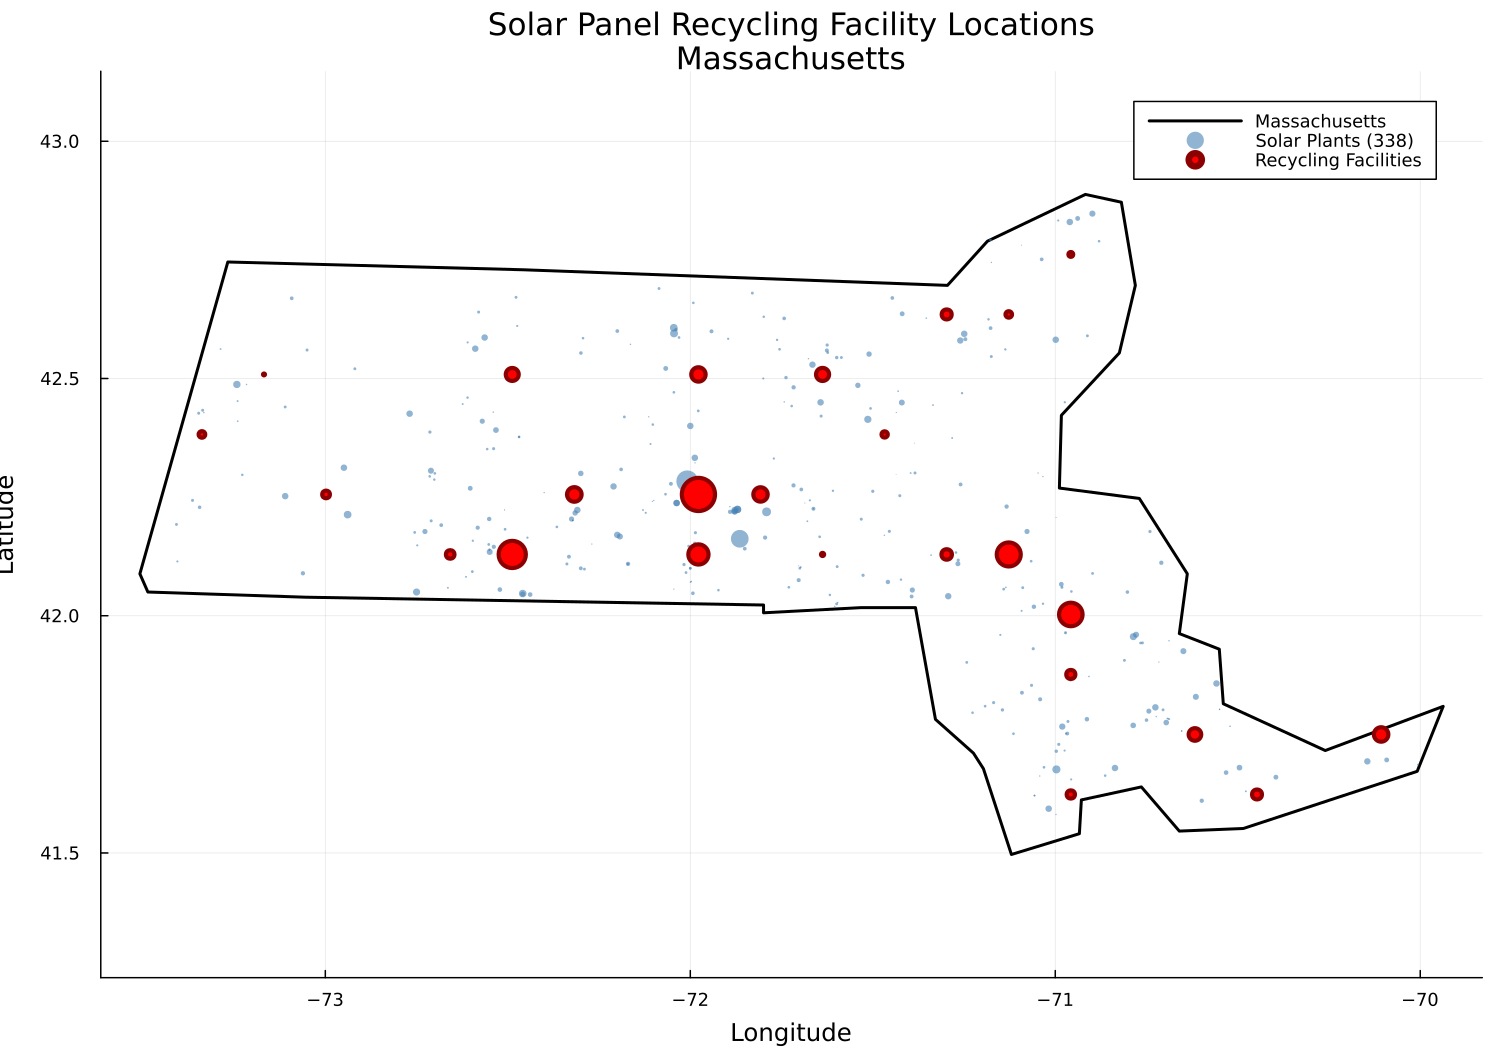

In [7]:
using HTTP, JSON, Plots
plant_locations = hcat(plant_details[:, 2], plant_details[:, 3])
possible_facilities = CSV.read("possible_facilities.csv", DataFrame; header=false) |> Matrix
# Function to download MA map
function get_ma_boundary()
    url = "https://raw.githubusercontent.com/python-visualization/folium/master/examples/data/us-states.json"
    response = HTTP.get(url)
    data = JSON.parse(String(response.body))
    
    # Find Massachusetts
    for feature in data["features"]
        if feature["properties"]["name"] == "Massachusetts"
            return feature["geometry"]["coordinates"]
        end
    end
    return nothing
end


ma_coords = get_ma_boundary()
ma_lons = Float64[]
ma_lats = Float64[]

if ma_coords !== nothing
    for polygon in ma_coords
        # Handle MultiPolygon structure
        if typeof(polygon[1][1]) <: AbstractVector
            for ring in polygon
                for coord in ring
                    push!(ma_lons, coord[1])
                    push!(ma_lats, coord[2])
                end
                push!(ma_lons, NaN)  # Break between polygons
                push!(ma_lats, NaN)
            end
        else
            for coord in polygon
                push!(ma_lons, coord[1])
                push!(ma_lats, coord[2])
            end
            push!(ma_lons, NaN)
            push!(ma_lats, NaN)
        end
    end
end


if termination_status(model) == MOI.OPTIMAL || termination_status(model) == MOI.TIME_LIMIT
    
    # Create plot with Massachusetts boundary
    p = plot(ma_lons, ma_lats,
        linecolor=:black,
        linewidth=2,
        fillalpha=0.1,
        fillcolor=:lightgray,
        label="Massachusetts",
        xlabel="Longitude",
        ylabel="Latitude",
        title="Solar Panel Recycling Facility Locations\nMassachusetts",
        legend=:topright,
        size=(1000, 700),
        dpi=150,
        aspect_ratio=1.3
    )
    
    # Plot solar plant locations
    scatter!(plant_locations[:, 2], plant_locations[:, 1],
        label="Solar Plants (338)",
        markersize=0.002*tons_waste,
        markercolor=:steelblue,
        alpha=0.6,
        markerstrokewidth=0
    )
    
    # Plot opened facilities with size proportional to capacity
    for (idx, i) in enumerate(open_facilities)
        size = y_val[i]
        size_factor =  0.002 * size
        scatter!([possible_facilities[i, 2]], [possible_facilities[i, 1]],
            label= i == open_facilities[1] ? "Recycling Facilities" : "",
            markersize=size_factor,
            markercolor=:red,
            markerstrokecolor=:darkred,
            markerstrokewidth=2
        )
    end
    
    display(p)
    # savefig(p, "facility_locations.png")
end

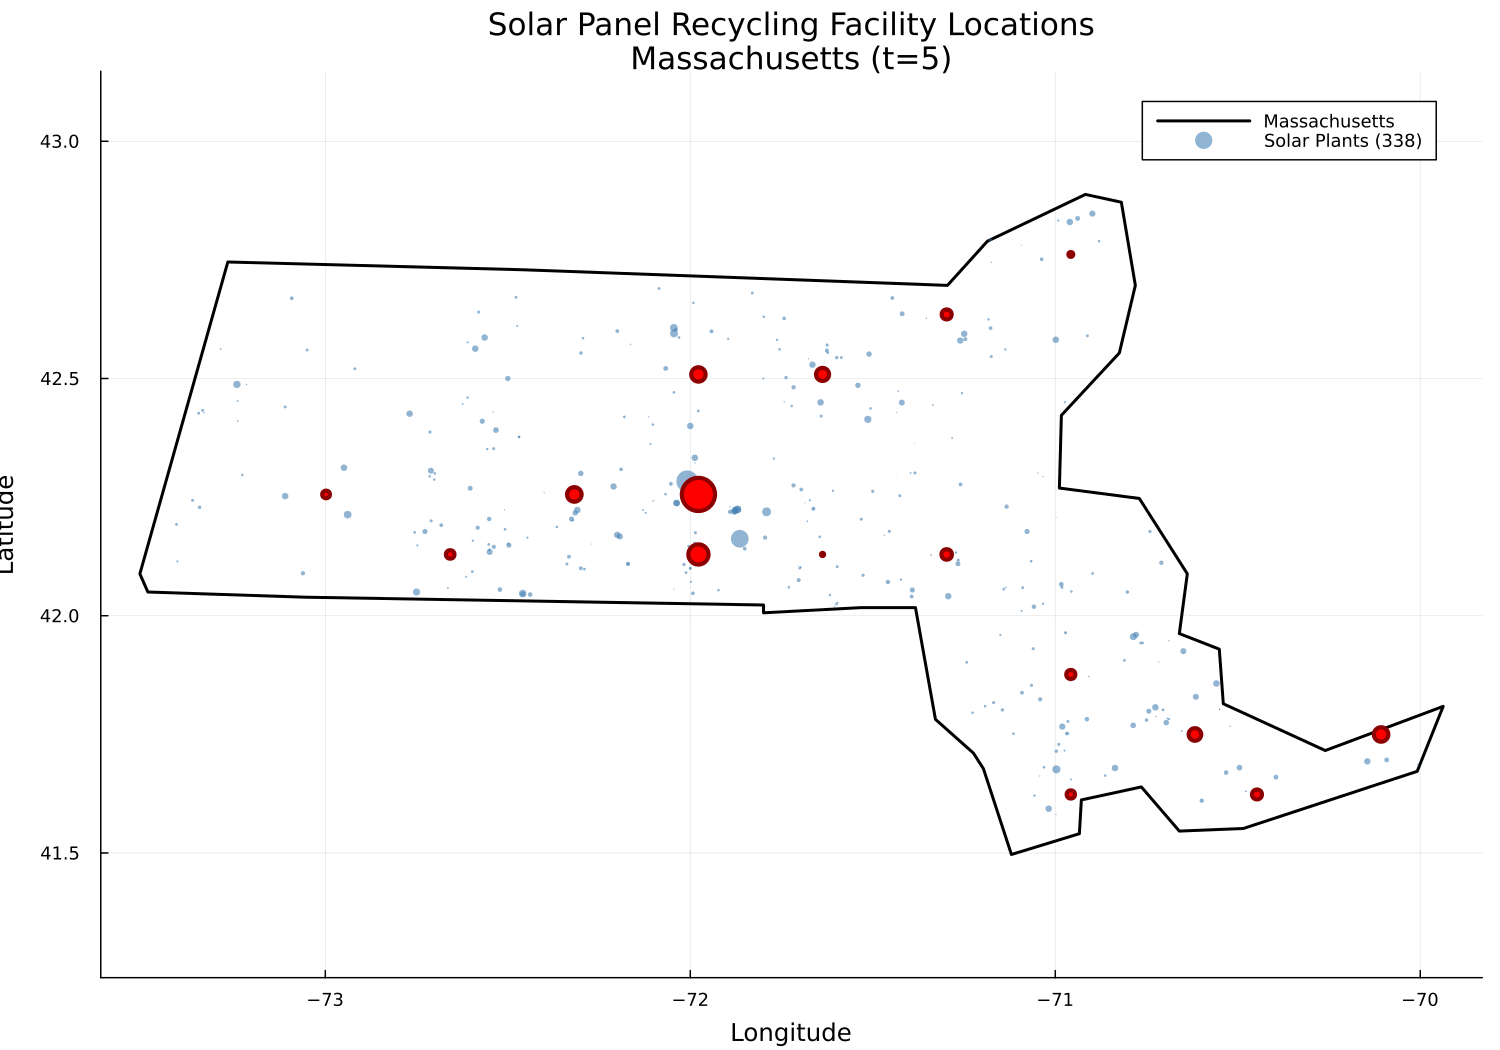

[2, 4, 9, 11, 14, 25, 29, 31, 33, 39, 43, 45, 74, 76, 91, 95]
2
4
9
11
14
25
29
31
33
39
43
45
74
76
91
95


In [43]:
plant_locations = hcat(plant_details[:, 2], plant_details[:, 3])
possible_facilities = CSV.read("possible_facilities.csv", DataFrame; header=false) |> Matrix
# Function to download MA map
function get_ma_boundary()
    url = "https://raw.githubusercontent.com/python-visualization/folium/master/examples/data/us-states.json"
    response = HTTP.get(url)
    data = JSON.parse(String(response.body))
    
    # Find Massachusetts
    for feature in data["features"]
        if feature["properties"]["name"] == "Massachusetts"
            return feature["geometry"]["coordinates"]
        end
    end
    return nothing
end


ma_coords = get_ma_boundary()
ma_lons = Float64[]
ma_lats = Float64[]

if ma_coords !== nothing
    for polygon in ma_coords
        # Handle MultiPolygon structure
        if typeof(polygon[1][1]) <: AbstractVector
            for ring in polygon
                for coord in ring
                    push!(ma_lons, coord[1])
                    push!(ma_lats, coord[2])
                end
                push!(ma_lons, NaN)  # Break between polygons
                push!(ma_lats, NaN)
            end
        else
            for coord in polygon
                push!(ma_lons, coord[1])
                push!(ma_lats, coord[2])
            end
            push!(ma_lons, NaN)
            push!(ma_lats, NaN)
        end
    end
end


if termination_status(model) == MOI.OPTIMAL || termination_status(model) == MOI.TIME_LIMIT
    
    # Create plot with Massachusetts boundary
    p = plot(ma_lons, ma_lats,
        linecolor=:black,
        linewidth=2,
        fillalpha=0.1,
        fillcolor=:lightgray,
        label="Massachusetts",
        xlabel="Longitude",
        ylabel="Latitude",
        title="Solar Panel Recycling Facility Locations\nMassachusetts (t=5)",
        legend=:topright,
        size=(1000, 700),
        dpi=150,
        aspect_ratio=1.3
    )
    
    # Plot solar plant locations
    scatter!(plant_locations[:, 2], plant_locations[:, 1],
        label="Solar Plants (338)",
        markersize=0.002*tons_waste,
        markercolor=:steelblue,
        alpha=0.6,
        markerstrokewidth=0
    )
    
    # Plot opened facilities with size proportional to capacity


    open_facilities_t5 = findall(x_val[:,5] .> 0.5)
    println(open_facilities_t5)
    for (idx, i) in enumerate(open_facilities_t5)
        println(i)
        size = y_val[i]
        size_factor =  0.002 * size
        scatter!([possible_facilities[i, 2]], [possible_facilities[i, 1]],
            label= i == open_facilties_t5[1] ? "Recycling Facilities" : "",
            markersize=size_factor,
            markercolor=:red,
            markerstrokecolor=:darkred,
            markerstrokewidth=2
        )
    end
    
    display(p)
    # savefig(p, "facility_locations.png")
end

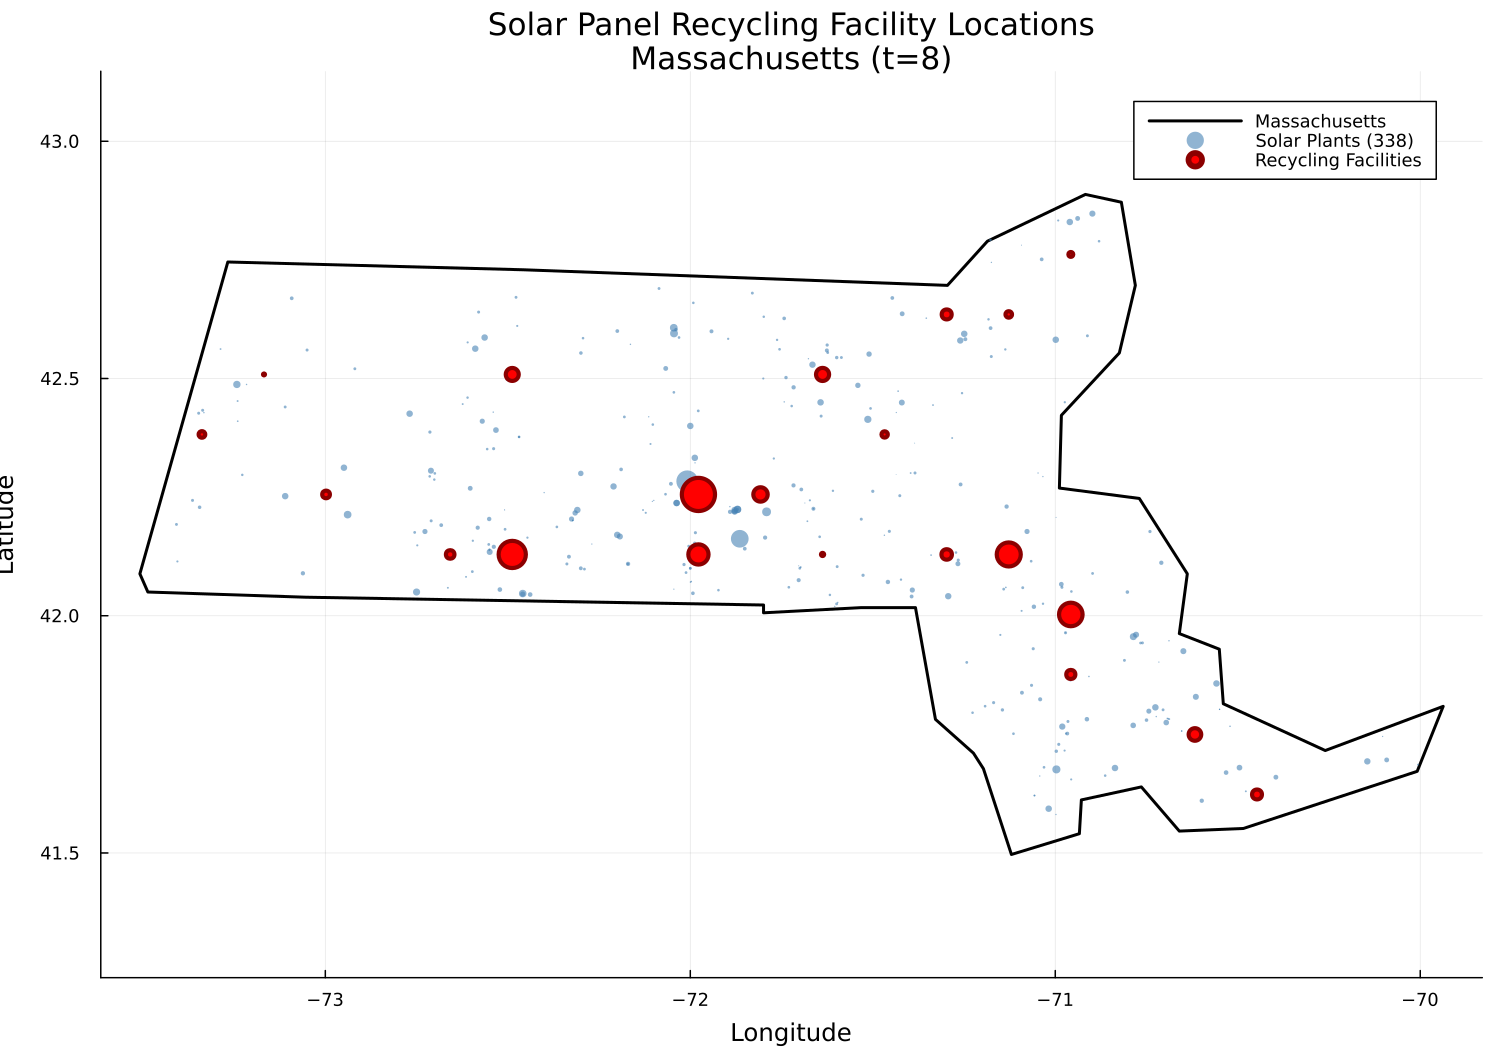

[4, 9, 14, 19, 25, 26, 29, 31, 33, 34, 39, 45, 46, 52, 63, 67, 71, 76, 91, 92, 95]
4
9
14
19
25
26
29
31
33
34
39
45
46
52
63
67
71
76
91
92
95


In [45]:
plant_locations = hcat(plant_details[:, 2], plant_details[:, 3])
possible_facilities = CSV.read("possible_facilities.csv", DataFrame; header=false) |> Matrix
# Function to download MA map
function get_ma_boundary()
    url = "https://raw.githubusercontent.com/python-visualization/folium/master/examples/data/us-states.json"
    response = HTTP.get(url)
    data = JSON.parse(String(response.body))
    
    # Find Massachusetts
    for feature in data["features"]
        if feature["properties"]["name"] == "Massachusetts"
            return feature["geometry"]["coordinates"]
        end
    end
    return nothing
end


ma_coords = get_ma_boundary()
ma_lons = Float64[]
ma_lats = Float64[]

if ma_coords !== nothing
    for polygon in ma_coords
        # Handle MultiPolygon structure
        if typeof(polygon[1][1]) <: AbstractVector
            for ring in polygon
                for coord in ring
                    push!(ma_lons, coord[1])
                    push!(ma_lats, coord[2])
                end
                push!(ma_lons, NaN)  # Break between polygons
                push!(ma_lats, NaN)
            end
        else
            for coord in polygon
                push!(ma_lons, coord[1])
                push!(ma_lats, coord[2])
            end
            push!(ma_lons, NaN)
            push!(ma_lats, NaN)
        end
    end
end


if termination_status(model) == MOI.OPTIMAL || termination_status(model) == MOI.TIME_LIMIT
    
    # Create plot with Massachusetts boundary
    p = plot(ma_lons, ma_lats,
        linecolor=:black,
        linewidth=2,
        fillalpha=0.1,
        fillcolor=:lightgray,
        label="Massachusetts",
        xlabel="Longitude",
        ylabel="Latitude",
        title="Solar Panel Recycling Facility Locations\nMassachusetts (t=8)",
        legend=:topright,
        size=(1000, 700),
        dpi=150,
        aspect_ratio=1.3
    )
    
    # Plot solar plant locations
    scatter!(plant_locations[:, 2], plant_locations[:, 1],
        label="Solar Plants (338)",
        markersize=0.002*tons_waste,
        markercolor=:steelblue,
        alpha=0.6,
        markerstrokewidth=0
    )
    
    # Plot opened facilities with size proportional to capacity


    open_facilities_t8 = findall(x_val[:,8] .> 0.5)
    println(open_facilities_t8)
    for (idx, i) in enumerate(open_facilities_t8)
        println(i)
        size = y_val[i]
        size_factor =  0.002 * size
        scatter!([possible_facilities[i, 2]], [possible_facilities[i, 1]],
            label= i == open_facilities_t8[1] ? "Recycling Facilities" : "",
            markersize=size_factor,
            markercolor=:red,
            markerstrokecolor=:darkred,
            markerstrokewidth=2
        )
    end
    
    display(p)
    # savefig(p, "facility_locations.png")
end